In [9]:
import Higgs.tools.Input as hinput
import glob
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt


def readbr(inp, oup):

    analyse_dir = inp#input("Directory to analyse: ")
    df = pd.DataFrame()
    for spcdir in glob.glob(analyse_dir+'*'):
        spcdata = hinput.readHB5SLHA(spcdir+'/SPheno.spc.THDMSZ3', [25, 35, 45,  36, 46], [37])
        df = df._append(spcdata,ignore_index=True)
    df.to_csv(oup)

# readbr('test/', 'br1.csv')
readbr('test/', 'br2.csv')



In [ ]:
from lib import analyselib as af
from lib import utilities as uti

import glob

df = pd.DataFrame()
# for spcdir in glob.glob('/home/licheng/Code/myscripts/sphenoscan/2hdms0/*'):
for spcdir in glob.glob('/home/licheng/Code/myscripts/4top/brmas/*'):
    dict_spc = dict()
    try:
        f_spc = glob.glob(spcdir+'/SPheno.spc.*')[0]
        spc = uti.read_spc(f_spc)
        dict_spc.update(af.read_mass(spc['BLOCK']['MASS']['values']))
        dict_spc.update(af.read_decay(spc['DECAY']))
        dict_spc.update(af.read_width(spc['DECAY']))
    except Exception as e:
        print(e)
    df = df._append(dict_spc, ignore_index=True)

# print(df['w_a2'])

df = df.sort_values(by=['ma1'])
df = df.set_index('ma1')

# print(df['br_a2tt'])


fig, ax = plt.subplots(1, 1)


# ax.plot(df.index, df['w_a2']*df['br_a2tt']     , label = r'$a_D\rightarrow tt$')
# ax.plot(df.index, df['w_a2']*df['br_a2a1h1']   , label = r'$a_D\rightarrow a_S h_{95}$')
# ax.plot(df.index, df['w_a2']*df['br_a2a1h2']   , label = r'$a_D\rightarrow a_S h_{125}$')
# ax.plot(df.index, df['w_a2']*df['br_a2bb']     , label = r'$a_D\rightarrow bb$')
# ax.plot(df.index, df['w_a2']*df['br_a2gluglu'], label = r'$a_D\rightarrow gg$')
# ax.plot(df.index, df['w_a2']*df['br_a2h2z']    , label = r'$a_D\rightarrow h_{125} Z$')
# ax.plot(df.index, df['w_a2']*df['br_a2h1z']    , label = r'$a_D\rightarrow h_{95} Z$')
ax.plot(df.index, df['br_a2tt']     , label = r'$a_D\rightarrow tt$')
ax.plot(df.index, df['br_a2a1h1']   , label = r'$a_D\rightarrow a_S h_{95}$')
ax.plot(df.index, df['br_a2a1h2']   , label = r'$a_D\rightarrow a_S h_{125}$')
ax.plot(df.index, df['br_a2bb']     , label = r'$a_D\rightarrow bb$')
ax.plot(df.index, df['br_a2gluglu'], label = r'$a_D\rightarrow gg$')
ax.plot(df.index, df['br_a2h2z']    , label = r'$a_D\rightarrow h_{125} Z$')
ax.plot(df.index, df['br_a2h1z']    , label = r'$a_D\rightarrow h_{95} Z$')

l1=ax.get_lines()[0]
l2=ax.get_lines()[1]
l3=ax.get_lines()[2]
l4=ax.get_lines()[3]
l5=ax.get_lines()[4]
l6=ax.get_lines()[5]
l7=ax.get_lines()[6]
# l8=ax.get_lines()[7
# l9=ax.get_lines()[8]
labellines(ax,l1,part=0.8,width=6, angle = 10)
labellines(ax,l2,part=0.2,width=8, angle = -5)
labellines(ax,l3,part=0.5,width=8, angle = -10)
labellines(ax,l4,part=0.5,width=6, angle = 15)
labellines(ax,l5,part=0.5,width=6, angle = 15)
labellines(ax,l6,part=0.5,width=7, angle = 15)
labellines(ax,l7,part=0.5,width=7, angle = 15)

ax.set_yscale('log')
ax.set_ylim(1e-4, 1.5)

# ax.axvline(550-95,color="black",lw=0.7,ls="--")
# ax.axvline(550-125,color="grey",lw=0.7,ls="--")
# ax.axvline(0,color="grey",lw=0.7,ls="--")

ax.minorticks_on()
ax.tick_params(axis="y",which='both',direction="in", right='true')
ax.tick_params(axis="x",which='both',direction="in", top='true')
ax.grid(alpha=0.3)
# ax.legend()

ax.set_xlabel('$m_{a_S}$ [GeV]')
ax.set_ylabel('Branching ratios')
ax.set_title(r'$\alpha_{4} = 3/4 \pi$')
plt.savefig('br_mas.png', dpi=100)

In [4]:
def brplt(pdgi,pdgo, pdg125, inp, ax, labo = r'$h_S$', legend=True):
    df = pd.read_csv(inp)
    df = df.sort_values(by=['m_'+str(pdgi)])
    ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_gg'], label=labo+r'$\rightarrow gg$', c = 'tab:pink')

    if not ( df['br_'+str(pdgo)+'_gamgam'] < 1e-4).all():
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_gamgam'], label =labo+ r'$\rightarrow \gamma\gamma$', c = 'tab:blue')
    if not (df['br_'+str(pdgo)+'_bb'] < 1e-4).all():
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_bb'], label=labo+r'$\rightarrow bb$', c = 'tab:orange')
    if not (df['br_'+str(pdgo)+'_cc'] < 1e-4).all():
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_cc'], label=labo+r'$\rightarrow cc$', c = 'tab:grey')
    if not (df['br_'+str(pdgo)+'_tautau'] < 1e-4).all():
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_tautau'], label=labo+r'$\rightarrow \tau\tau$', c = 'tab:green')
    try:
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_WW'], label=labo+r'$\rightarrow WW$', c = 'tab:purple')
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_ZZ'], label=labo+r'$\rightarrow ZZ$', c = 'tab:brown')
    except:
        pass
    try:
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_tt'], label=labo+r'$\rightarrow tt$', c = 'tab:red')
    except:
        pass
    try:
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_'+str(pdgi)+'_'+str(pdgi)], label=labo+r'$\rightarrow h_S h_S$', c = 'b')
    except:
        pass
    try:
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_'+str(pdg125)+'_'+str(pdg125)], label=labo+r'$\rightarrow h h$', c = 'tab:olive')
    except:
        pass
    try:
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_25_35'], label=labo+r'$\rightarrow h_S h$', c = 'tab:cyan')
    except:
        pass

    try:
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_Z_'+str(pdgi)], label=labo+r'$\rightarrow  Z h_S$', c = 'b')
    except:
        pass
    try:
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_Z_'+str(pdg125)], label=labo+r'$\rightarrow Z h$', c = 'tab:olive')
    except:
        pass
    try:
        ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_'+str(pdg125)+'_36'], label=labo+r'$\rightarrow h A_S$', c = 'tab:cyan')
    except:
        pass


    if legend:
        ax.legend()

# def wthplt(pdgi,pdgo, pdg125, inp, ax, labo = r'$h_S$', legend=True):
#     df = pd.read_csv(inp)
#     df = df.sort_values(by=['m_'+str(pdgi)])
#     ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_gg']*df['w_'+str(pdgo)], label=labo+r'$\rightarrow gg$', c = 'tab:pink')

#     if not ( df['br_'+str(pdgo)+'_gamgam'] < 1e-4).all():
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_gamgam']*df['w_'+str(pdgo)], label =labo+ r'$\rightarrow \gamma\gamma$', c = 'tab:blue')
#     if not (df['br_'+str(pdgo)+'_bb'] < 1e-4).all():
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_bb']*df['w_'+str(pdgo)], label=labo+r'$\rightarrow bb$', c = 'tab:orange')
#     if not (df['br_'+str(pdgo)+'_cc'] < 1e-4).all():
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_cc']*df['w_'+str(pdgo)], label=labo+r'$\rightarrow cc$', c = 'tab:grey')
#     if not (df['br_'+str(pdgo)+'_tautau'] < 1e-4).all():
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_tautau']*df['w_'+str(pdgo)], label=labo+r'$\rightarrow \tau\tau$', c = 'tab:green')
#     try:
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_WW']*df['w_'+str(pdgo)], label=labo+r'$\rightarrow WW$', c = 'tab:purple')
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_ZZ']*df['w_'+str(pdgo)], label=labo+r'$\rightarrow ZZ$', c = 'tab:brown')
#     except:
#         pass
#     try:
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_tt']*df['w_'+str(pdgo)], label=labo+r'$\rightarrow tt$', c = 'tab:red')
#     except:
#         pass
#     try:
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_'+str(pdgi)+'_'+str(pdgi)]*df['w_'+str(pdgo)], label=labo+r'$\rightarrow h_S h_S$', c = 'b')
#     except:
#         pass
#     try:
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_'+str(pdg125)+'_'+str(pdg125)]*df['w_'+str(pdgo)], label=labo+r'$\rightarrow h h$', c = 'tab:olive')
#     except:
#         pass
#     try:
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_25_35']*df['w_'+str(pdgo)], label=labo+r'$\rightarrow h_S h$', c = 'tab:cyan')
#     except:
#         pass

#     try:
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_Z_'+str(pdgi)]*df['w_'+str(pdgo)], label=labo+r'$\rightarrow  Z h_S$', c = 'b')
#     except:
#         pass
#     try:
#         ax.plot(df['m_'+str(pdgi)], df['br_'+str(pdgo)+'_Z_'+str(pdg125)]*df['w_'+str(pdgo)], label=labo+r'$\rightarrow Z h$', c = 'tab:olive')
#     except:
#         pass

#     if legend:
#         ax.legend()



Text(0.5, 1.0, 'Branching ratios of $A$')

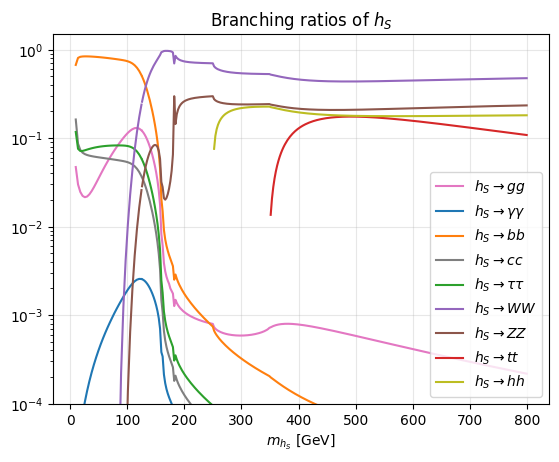

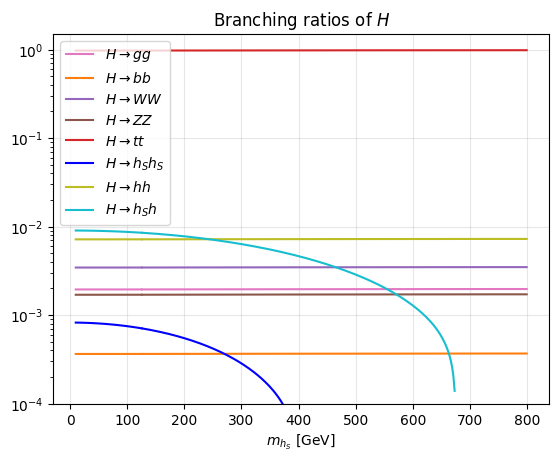

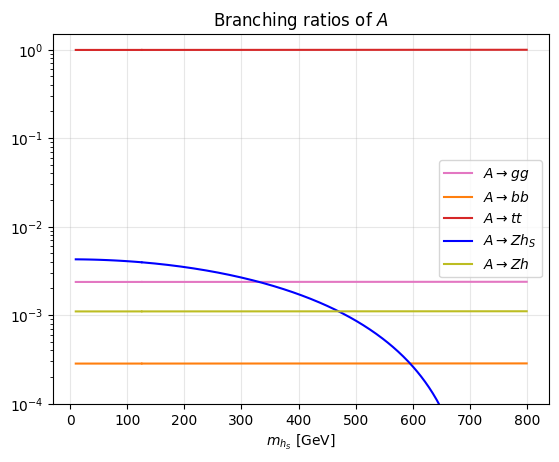

In [10]:
fig, ax1 = plt.subplots(1,1)

# ax1 = ax
brplt('35','35', '25', './br2.csv', ax1)
brplt('25','25', '35', './br1.csv', ax1, legend=False)
# ax.plot(df['m_25'], df['br_25_Z_25'], label=r'$a_S\rightarrow Z h_S$')

ax1.set_yscale('log')
ax1.grid(alpha=0.3)
# ax.set_xscale('log')
ax1.set_ylim(0.0001, 1.5)
ax1.set_xlabel(r'$m_{h_S}$ [GeV]')
ax1.set_title(r'Branching ratios of $h_S$')


fig, ax2 = plt.subplots(1,1)
brplt('35','45', '25', './br2.csv', ax2, labo='$H$')
brplt('25','45', '35', './br1.csv', ax2, legend=False)
ax2.set_yscale('log')
ax2.grid(alpha=0.3)
ax2.set_ylim(0.0001, 1.5)
ax2.set_xlabel(r'$m_{h_S}$ [GeV]')
ax2.set_title(r'Branching ratios of $H$')



fig, ax3 = plt.subplots(1,1)
brplt('35','36', '25', './br2.csv', ax3, labo='$A$')
brplt('25','36', '35', './br1.csv', ax3, legend=False)
ax3.set_yscale('log')
ax3.grid(alpha=0.3)
ax3.set_ylim(0.0001, 1.5)
ax3.set_xlabel(r'$m_{h_S}$ [GeV]')
ax3.set_title(r'Branching ratios of $A$')

# fig, ax4 = plt.subplots(1,1)
# # brplt('35','25', '25', 'br/br2.csv', ax4, legend=False)
# brplt('25','35', '35', 'br/br1.csv', ax4, labo='$h$')
# ax4.set_yscale('log')
# ax4.grid(alpha=0.3)
# ax4.set_xlim(0, 100)
# ax4.set_ylim(0.0001, 1.5)
# ax4.set_xlabel(r'$m_{h_S}$ [GeV]')
# ax4.set_title(r'Branching ratios of $h$')

# varying $A_s$ mass

Text(0.5, 1.0, 'Branching ratios of $A$')

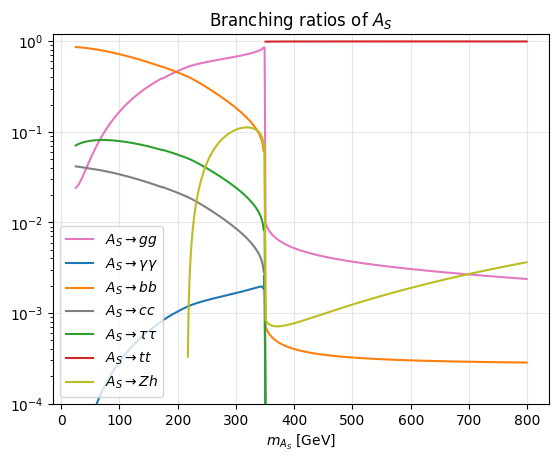

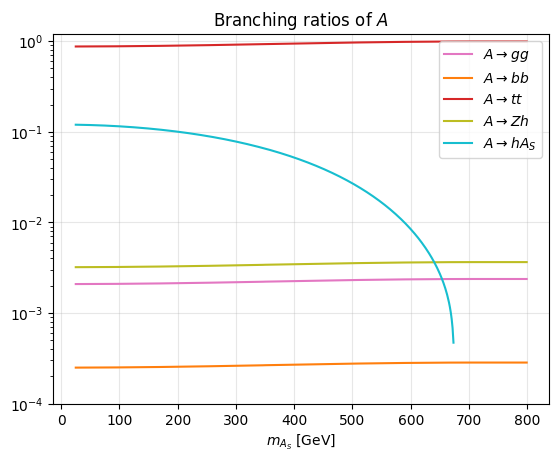

In [39]:

# readbr('test/', 'bra1.csv')

fig, ax1 = plt.subplots(1,1)

brplt('36','36', '25', 'bra1.csv', ax1, labo='$A_S$')

ax1.set_yscale('log')
ax1.set_ylim(0.0001, 1.2)
ax1.grid(alpha=0.3)
ax1.set_xlabel(r'$m_{A_S}$ [GeV]')
ax1.set_title(r'Branching ratios of $A_S$')

fig, ax2 = plt.subplots(1,1)

brplt('36','46', '25', 'bra1.csv', ax2, labo='$A$')

ax2.set_yscale('log')
ax2.set_ylim(0.0001, 1.2)
ax2.grid(alpha=0.3)
ax2.set_xlabel(r'$m_{A_S}$ [GeV]')
ax2.set_title(r'Branching ratios of $A$')

(0.0001, 1.2)

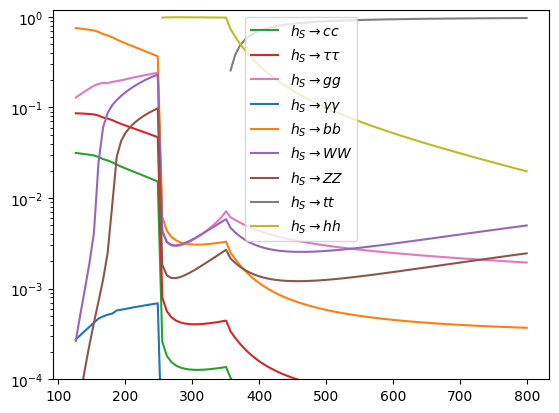

In [92]:

readbr('test/', 'br10.csv')
fig, ax = plt.subplots(1,1)

brplt('35','35', '25', 'br10.csv', ax)

ax.set_yscale('log')
ax.set_ylim(0.0001, 1.2)

(0.0001, 1.1)

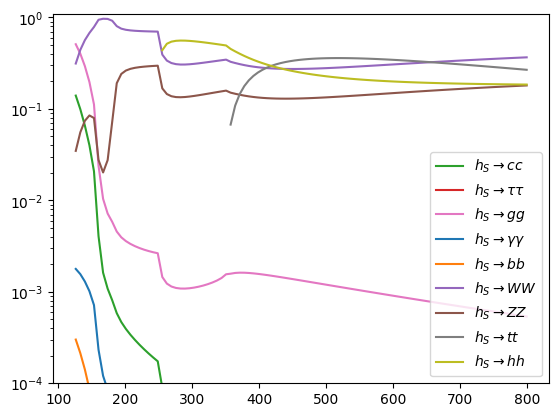

In [17]:

readbr('test/', 'br11.csv')
fig, ax = plt.subplots(1,1)

brplt('35', 'br11.csv', ax)

ax.set_yscale('log')
ax.set_ylim(0.0001, 1.1)